*@author: petra.boskovic*

## Emotion Recognition: Natural Language Processing with TensorFlow

## Task 1: Setup and Imports

In [1]:
#!pip install nlp
#!pip install datasets
#!pip install tensorflow

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
#import nlp
import random

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from google.colab import drive, files, userdata

import warnings
warnings.filterwarnings('ignore')

In [3]:
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/data science/deep learning/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
pd.set_option('display.max_columns', None)

In [5]:
def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()

## Task 2: Importing Data:

1. Importing the Emotion dataset
2. Creating train, validation and test sets
3. Extracting text and labels from the examples

In [6]:
df = load_dataset("dair-ai/emotion", "split")

In [7]:
df

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

### **Label dictionary**
'0': **sadness**  
'1': **joy**  
'2': **love**  
'3': **anger**  
'4': **fear**  
'5': **surprise**

In [8]:
train = df['train']
val = df['validation']
test = df['test']

In [9]:
def get_text(data):
  text = [x['text'] for x in data]
  labels = [x['label'] for x in data]
  return text, labels

In [10]:
text, labels = get_text(train)

In [11]:
text[1], labels[1]

('i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 0)

## Task 3: Tokenizer

In [12]:
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')
tokenizer.fit_on_texts(text)

In [13]:
tokenizer.texts_to_sequences([text[0]])

[[2, 139, 3, 679]]

In [14]:
text[0]

'i didnt feel humiliated'

## Task 4: Padding and Truncating Sequences

1. Checking length of the text
2. Creating padded sequences

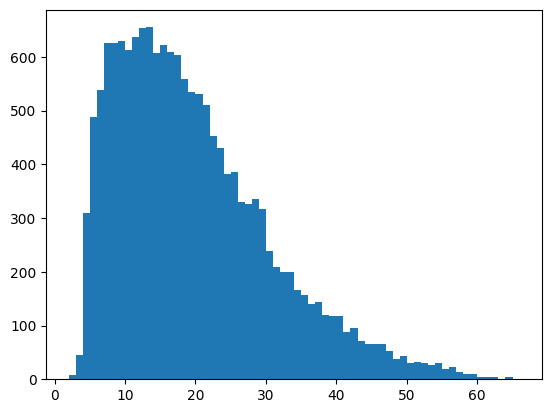

In [15]:
lengths = [len(t.split(' ')) for t in text]
plt.hist(lengths, bins = len(set(lengths)))
plt.show()

In [16]:
def get_sequences(tokenizer, text):
  sequences = tokenizer.texts_to_sequences(text)
  padded = pad_sequences(sequences, truncating= 'post', padding= 'post', maxlen= 50)
  return padded

In [17]:
padded_train_seq = get_sequences(tokenizer, text)
padded_train_seq[0]  # there is 50 values

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

## Task 5: Preparing the Labels

1. Creating classes to index and index to classes dictionaries
2. Converting text labels to numeric labels

In [18]:
classes = set(labels)
classes

{0, 1, 2, 3, 4, 5}

In [19]:
index_to_class = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

index_to_class

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

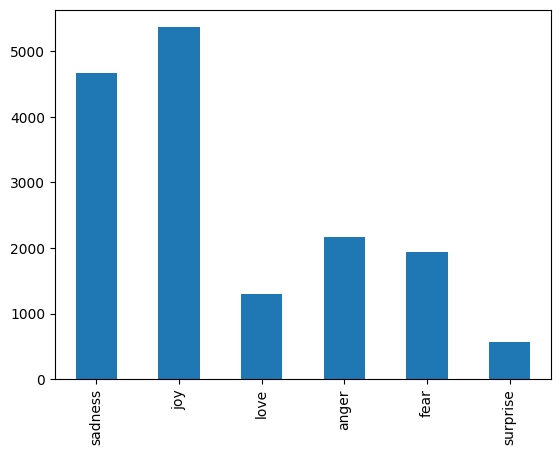

In [20]:
s = pd.Series(labels)

s_named = s.map(index_to_class)

counts = s_named.value_counts().reindex(list(index_to_class.values()))

counts.plot(kind='bar')
plt.show()

## Task 6: Creating the Model

1. Creating the model
2. Compiling the model

In [21]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16, input_shape = (50,)),  # input, output
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(6, activation='softmax')  # 6 output classes
])

model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 16)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 40)         │         5,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 40)             │         9,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,926 (687.21 KB)

 Trainable params: 175,926 (687.21 KB)

 Non-trainable params: 0 (0.00 B)

## Task 7: Training the Model

1. Preparing a validation set
2. Training the model

In [23]:
val_text, val_labels = get_text(val)
val_seq = get_sequences(tokenizer, val_text)

In [24]:
val_text[0], val_labels[0]

('im feeling quite sad and sorry for myself but ill snap out of it soon', 0)

In [25]:
h = model.fit(
    padded_train_seq, np.array(labels, dtype='int32'),
    validation_data = (val_seq, np.array(val_labels, dtype='int32')),
    epochs = 20,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2) # If it doesnt see improvements in acc in 2 epochs it will stop
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.4466 - loss: 1.3858 - val_accuracy: 0.6895 - val_loss: 0.8840
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.7726 - loss: 0.6556 - val_accuracy: 0.7890 - val_loss: 0.6266
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8554 - loss: 0.4209 - val_accuracy: 0.8315 - val_loss: 0.5358
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9075 - loss: 0.2952 - val_accuracy: 0.8570 - val_loss: 0.4624
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9316 - loss: 0.2206 - val_accuracy: 0.8570 - val_loss: 0.4676
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9476 - loss: 0.1704 - val_accuracy: 0.8600 - val_loss: 0.4938
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9521 - loss: 0.1617 - val_accuracy: 0.8635 - val_loss: 0.4860
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9653 - loss: 0.1156 - 

## Task 8: Evaluating the Model

1. Visualizing training history
2. Prepraring a test set
3. A look at individual predictions on the test set
4. A look at all predictions on the test set

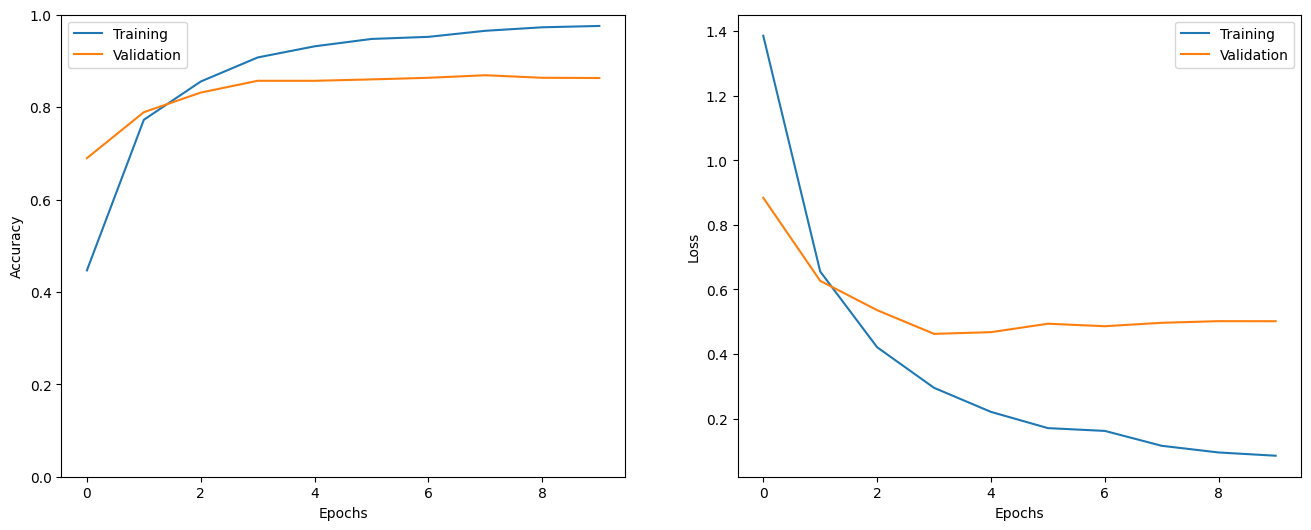

In [26]:
show_history(h)

In [27]:
test_text, test_labels = get_text(test)
test_seq = get_sequences(tokenizer, test_text)
test_labels = np.array(test_labels, dtype='int32')

In [28]:
_ = model.evaluate(test_seq, test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8655 - loss: 0.4911


In [29]:
i = random.randint(0, len(test_labels) - 1)

print('Sentence:', test_text[i])
#print('Emotion: ', test_labels[i])
print('Emotion:', index_to_class[test_labels[i]])

p = model.predict(np.expand_dims(test_seq[i], axis = 0))[0]   # expand_dims - to make the appropriate shape for one example

#print("Predicted emotion: ", np.argmax(p))
print("Predicted emotion:", index_to_class[np.argmax(p)])

Sentence: im feeling cranky a href http doingaone eighty
Emotion: anger
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step
Predicted emotion: anger


In [30]:
probabilities = model.predict(test_seq)
preds = np.argmax(probabilities, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


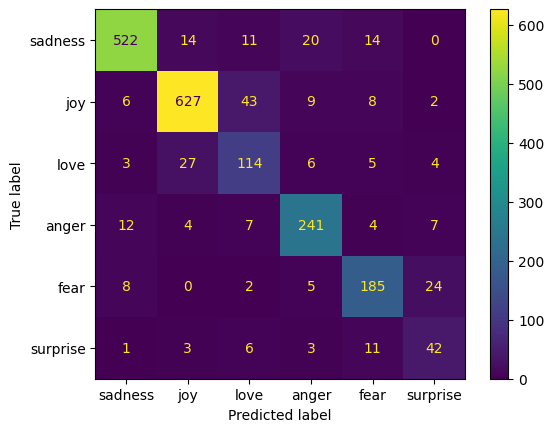

In [31]:
cm = confusion_matrix(test_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(index_to_class.values()))
disp.plot()
plt.show()